# Shap and FAR synthetic data tests

In [1]:
import sys

!{sys.executable} -m pip install nbimporter

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbimporter
import sklearn.ensemble
import xgboost as xgb
import shap

import synthetic_data as syn
import Ft_Att_Rank as far

# Load synthetic dataset

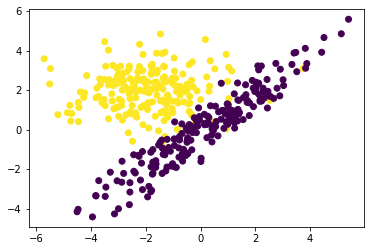

In [3]:
synth= syn.synthetic_data_generator(n=200,df=True)

X= synth.to_numpy()

plt.scatter(X[:,0],X[:,1],c=X[:,-1])

In [4]:
# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

x_syn= far.normalize_selected_cols(x_syn, x_syn.columns)

In [5]:
x_syn.head()

,core_1,core_2,noise_1,noise_2
0,0.132844,0.627710,0.008976,0.441206
1,0.240310,0.710252,0.211908,0.403695
2,0.310884,0.695171,0.367124,0.049578
3,0.090337,0.523597,0.735211,0.030018
4,0.484260,0.690992,0.148354,0.788646


# ML model setup

In [6]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_syn,y_syn,train_size=0.80,
                                                                                 random_state=1234)

In [8]:
# ML model - XGBoost random forest
xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss')
xgb_model.fit(train, labels_train.values.ravel())
xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

0.9625

In [9]:
# ML model - Random forest
rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)
rf.fit(train, labels_train.values.ravel())
rf_acc= sklearn.metrics.accuracy_score(labels_test, rf.predict(test))

rf_acc

0.95

# Shap test

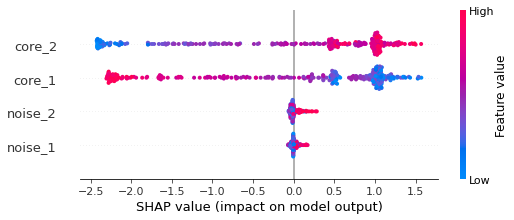

In [11]:
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values)

In [12]:
shap_values[1]

.values =
array([-2.2240894 ,  0.6316036 , -0.03445411,  0.05104291], dtype=float32)

.base_values =
-0.06290152

.data =
array([0.71343841, 0.76355929, 0.49319517, 0.80361856])

# FAR test - Global version

In [14]:
repeat_train= 5
num_fts= len(train.columns)

acc_all_fts= far.train_model_get_acc_mean(xgb_model, train, test, labels_train.values.ravel(), 
                                          labels_test.values.ravel(), repeat_train)

replace_ft= far.replace_values(train,train.columns,num_type='mean')

acc_no_i, acc_no_ij= far.remove_and_retrain_v1(xgb_model, replace_ft, train, test, labels_train,labels_test, 
                                               repeat_train)

In [15]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# finding the stationary distribution
st_matrix1= np.asarray(p_matrix1)
st_matrix2= np.asarray(p_matrix2)
st_matrix3= np.asarray(p_matrix3)
st_matrix4= np.asarray(p_matrix4)

# now convert to right stochastic matrix - a real square matrix, with each row summing to 1
st_matrix1= far.to_row_stochastic_matrix(st_matrix1)
st_matrix2= far.to_row_stochastic_matrix(st_matrix2)
st_matrix3= far.to_row_stochastic_matrix(st_matrix3)
st_matrix4= far.to_row_stochastic_matrix(st_matrix4)

# get the stationary distribution
stationary_d1= far.stationary_dist_v1(st_matrix1)
stationary_d2= far.stationary_dist_v1(st_matrix2)
stationary_d3= far.stationary_dist_v1(st_matrix3)
stationary_d4= far.stationary_dist_v1(st_matrix4)

In [16]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.454326
core_2     0.424488
noise_1    0.090865
noise_2    0.030321
dtype: float64

In [17]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.295281
core_2     0.275784
noise_1    0.222944
noise_2    0.205990
dtype: float64

In [18]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.297564
core_2     0.288038
noise_1    0.211379
noise_2    0.203020
dtype: float64

In [19]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.477548
core_2     0.462942
noise_1    0.045481
noise_2    0.014029
dtype: float64

# FAR test - Knn-only local version

In [20]:
X_to_split= x_syn.copy()
Y_to_split= y_syn.copy()

target_index= 1

target_instance= X_to_split.loc[X_to_split.index== target_index]
target_label= Y_to_split.loc[Y_to_split.index== target_index]

X_no_targt= X_to_split.drop(target_instance.index)
Y_no_targt= Y_to_split.drop(index= target_index)

In [28]:
train_1, test_1, labels_train_1, labels_test_1= far.knn_train_test_split(X_no_targt,Y_no_targt,target_instance,
                                                                         target_label,test_size=0.2)

repeat_train= 5
num_fts= len(train_1.columns)

acc_all_fts= far.train_model_get_acc_mean(xgb_model, train_1, test_1, labels_train_1.values.ravel(), 
                                          labels_test_1.values.ravel(), repeat_train)

replace_ft= far.replace_values(train,train.columns,num_type='mean')

acc_no_i, acc_no_ij= far.remove_and_retrain_v1(xgb_model, replace_ft, train_1, test_1, 
                                               labels_train_1.values.ravel(),
                                               labels_test_1.values.ravel(), repeat_train)

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].


In [29]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# finding the stationary distribution
st_matrix1= np.asarray(p_matrix1)
st_matrix2= np.asarray(p_matrix2)
st_matrix3= np.asarray(p_matrix3)
st_matrix4= np.asarray(p_matrix4)

# now convert to right stochastic matrix - a real square matrix, with each row summing to 1
st_matrix1= far.to_row_stochastic_matrix(st_matrix1)
st_matrix2= far.to_row_stochastic_matrix(st_matrix2)
st_matrix3= far.to_row_stochastic_matrix(st_matrix3)
st_matrix4= far.to_row_stochastic_matrix(st_matrix4)

# get the stationary distribution
stationary_d1= far.stationary_dist_v1(st_matrix1)
stationary_d2= far.stationary_dist_v1(st_matrix2)
stationary_d3= far.stationary_dist_v1(st_matrix3)
stationary_d4= far.stationary_dist_v1(st_matrix4)

In [30]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_1    0.302628
core_2     0.266051
core_1     0.238113
noise_2    0.193208
dtype: float64

In [31]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_2    0.295570
core_1     0.256307
core_2     0.246620
noise_1    0.201503
dtype: float64

In [32]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.285615
core_2     0.273004
noise_2    0.236309
noise_1    0.205072
dtype: float64

In [33]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.333567
core_2     0.321984
noise_1    0.212525
noise_2    0.131923
dtype: float64

# FAR test - Local version PageRank

In [34]:
far.run_lib_pr(st_matrix1, x_syn.columns)

noise_1    0.294945
core_2     0.263004
core_1     0.240665
noise_2    0.201385
dtype: float64

In [35]:
far.run_lib_pr(st_matrix2, x_syn.columns)

noise_2    0.288717
core_1     0.256030
core_2     0.246574
noise_1    0.208679
dtype: float64

In [36]:
far.run_lib_pr(st_matrix3, x_syn.columns)

core_1     0.282320
core_2     0.270750
noise_2    0.236752
noise_1    0.210179
dtype: float64

In [37]:
far.run_lib_pr(st_matrix4, x_syn.columns)

core_1     0.324723
core_2     0.314379
noise_1    0.214007
noise_2    0.146891
dtype: float64

In [38]:
far.run_my_pr(st_matrix1, x_syn.columns)

core_2     0.343215
core_1     0.333588
noise_1    0.181210
noise_2    0.141988
dtype: float64

In [39]:
far.run_my_pr(st_matrix2, x_syn.columns)

core_1     0.349268
core_2     0.326611
noise_2    0.176832
noise_1    0.147288
dtype: float64

In [40]:
far.run_my_pr(st_matrix3, x_syn.columns)

core_1     0.406153
core_2     0.300469
noise_2    0.148116
noise_1    0.145262
dtype: float64

In [41]:
far.run_my_pr(st_matrix4, x_syn.columns)

core_1     0.458421
core_2     0.295019
noise_1    0.136987
noise_2    0.109574
dtype: float64